In [1]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression as LOR
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from generalized_contrastive_PCA import gcPCA
from scipy.stats import median_abs_deviation as MAD

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

### Channel labels

In [2]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

### Subject labels

In [3]:
data_dir = '../../data/preprocessed_data/'
out_path = '../../data/derivatives/'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


### Aggregating burst features of the STN and of motor cortex (C3,C4) across all subjects

In [4]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


In [5]:
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject)
    off_med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']=='OFF')])
    max_off_trial = np.max(off_med_trials)
    on_med_idx = subj_idx & (all_bursts['med']=='ON')
    all_bursts['trial'][on_med_idx] = all_bursts['trial'][on_med_idx] + max_off_trial + 1 

### Select bursts corresponding to C3/C4 and all STN contacts

### Plot the beta burst waveform for sensorimotor cortex (C3,C4) Vs STN 

In [6]:
burst_times = all_bursts['waveform_times'] * 1000 

In [7]:
def reject_outliers(X, m=3, scaling=False):
    """
    Adapted from https://medium.com/@saraswatp/exploring-data-anomalies-rejecting-outliers-with-python-660b1ed6bca6
    Returns a boolean mask where True = 'Keep' and False = 'Outlier'.
    """
    median = np.median(X, axis=0)
    # mad = MAD(X, axis=0, scale='normal')

    if scaling:
        mad = np.median(np.abs(X - median), axis=0) * 1.4826
    else:
        mad = np.median(np.abs(X - median), axis=0)
    
    upper_bound = median + m * mad
    lower_bound = median - m * mad

    mask = (X >= lower_bound) & (X <= upper_bound)

    return mask


def reject_outliers_by_subject_channel(burst_dict, value_key='peak_amp_base', m=3, scaling=False):
    """Compute outlier mask separately within each subject x chennel group.

    Args:
        burst_dict (dictionary): Burst dictionary containing at least:
            - 'subject'
            - 'channel'
            - value_key
        
        value_key (str, optional): Name of the feature on which to reject outliers. Defaults to 'peak_amp_base'.
        m (float, optional): Number of MADs from the median used as the cutoff. Defaults to 3.
        scaling (bool, optional): If True, scale MAD by 1.4826. Defaults to False.
    
    Returns:
        group_mask: ndarray of bool, shape (n_bursts,). Global mask with True = keep, False = outlier.
    """

    values = np.asarray(burst_dict[value_key])
    subjects_arr = np.asarray(burst_dict['subject'])
    channels_arr = np.asarray(burst_dict['channel'])

    n = len(values)
    if not (len(subjects_arr) == n and len(channels_arr) == n):
        raise ValueError(f"'subject', 'channel', and '{value_key}' must have the same length." )
    
    group_mask = np.ones(n, dtype=bool)
    unique_subjects = np.unique(subjects_arr)

    for sub in unique_subjects:
        sub_idx = subjects_arr == sub
        sub_channels = np.unique(channels_arr[sub_idx])

        for ch in sub_channels:
            idx = sub_idx & (channels_arr == ch)

            # Reject within this subject x channel subset
            local_mask = reject_outliers(values[idx], m=m, scaling=scaling)

            # Write local decisions back into full-length mask
            group_mask[idx] = local_mask

    return group_mask



In [8]:
def scaler_fit(X):
    median = np.median(X, axis=0)
    mad = MAD(X, axis=0, scale='normal')
    return median, mad


def scaler_transform(X, median, mad):
    return (X - median) / mad

In [9]:
def get_features_and_labels(gcPC_scores, bursts_dict, type_subs, cols_idx, n_bins, area):
    """
    Function to build the feature matrix and label vector for the logistic regression classifier.
    It takes as input the gcPC scores for all bursts, the bursts dictionary, the indices of the gcPCs
    to consider, the number of bins to use for each gcPC, the number of MADs to use for outlier
    rejection when building trial-level features, and the area to consider (STN or cortical).
    """
    
    max_type_subs = sum(len(np.unique(bursts_dict['trial'][bursts_dict['subject'] == sub])) for sub in type_subs)
    X = np.zeros((max_type_subs, len(cols_idx) * n_bins))
    y = np.zeros(max_type_subs)

    r = 0
    for i in range(len(type_subs)):
        type_sub = type_subs[i]
        
        # compute percentile bin limits using subject bursts only
        subject_bursts_idx = (bursts_dict['subject'] == type_sub) & area
        if np.sum(subject_bursts_idx) == 0:
            print(f'Warning: No bursts found for subject {type_sub} in the selected area ({area}). '
                  'Skipping this subject for percentile bin limit computation.')
            continue

        pc_bin_lims = np.zeros((len(cols_idx), n_bins + 1))
        for col_idx, col in enumerate(cols_idx):
            pc_bin_lims[col_idx, :] = np.percentile(gcPC_scores[subject_bursts_idx, col], np.linspace(0, 100, n_bins + 1))

        # Build trial-level features across all cortex trials
        trials = np.unique(bursts_dict['trial'][(bursts_dict['subject'] == type_sub)])
        for trial in trials:
            burst_idx = area & (bursts_dict['trial'] == trial) & (bursts_dict['subject'] == type_sub)
            label = np.unique(bursts_dict['med'][burst_idx])[0]
            
            row = np.zeros(len(cols_idx) * n_bins, dtype=float)  # Pre-allocate row with zeros for gcPC-bin combinations with no bursts
            for col_idx, col in enumerate(cols_idx):
                for bin in range(n_bins):
                    lower = pc_bin_lims[col_idx, bin]
                    higher = pc_bin_lims[col_idx, bin+1]
                    count = np.sum((gcPC_scores[burst_idx, col] >= lower) &
                                    (gcPC_scores[burst_idx, col] < higher))
                    row[col_idx * n_bins + bin] = count
            # if np.sum(row) > 0:  # Only include trials with at least one burst in the selected gcPCs
            #     row /= np.sum(row)  # Normalize row to sum to 1 (relative distribution of bursts across gcPC bins)
            X[r, :] = row
            y[r] = 0 if label == 'OFF' else 1
            r += 1

    X = X[:r]
    y = y[:r]

    return X, y

In [10]:
outlier_mask = reject_outliers_by_subject_channel(
    all_bursts,
    value_key='peak_amp_base',
    m=3,
    scaling=False
    )

len_mask = len(outlier_mask)

correct_bursts = {
    key: (value[outlier_mask] if len(value) == len_mask else value)
    for key, value in all_bursts.items()
    }

# print(f"Original trials: {len(all_bursts['peak_amp_base'])}")
# print(f"Corrected trials: {len(correct_bursts['peak_amp_base'])}")
# print(f"Removed trials: {len(all_bursts['peak_amp_base']) - len(correct_bursts['peak_amp_base'])}")

In [11]:
c_idx = (correct_bursts['channel']=='C3') | (correct_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in correct_bursts['channel']]

In [12]:
on_idx = (correct_bursts['med']=='ON')
off_idx = (correct_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [13]:
area = stn_idx

# Scale waveforms within subject such as (X - median)/IQR 
scaled_waveforms = np.zeros_like(correct_bursts['waveform'])

for subject in np.unique(correct_bursts['subject']):
    subj_idx = (correct_bursts['subject'] == subject)
    # scaler = RobustScaler().fit(correct_bursts['waveform'][subj_idx & area])                # .fit() returns the median and IQR values
    # scaler = StandardScaler().fit(correct_bursts['waveform'][subj_idx & area])              # .fit() returns the mean and std values
    # scaled_waveforms[subj_idx, :] = scaler.transform(correct_bursts['waveform'][subj_idx])  # .transform() does the maths.

    median, mad = scaler_fit(correct_bursts['waveform'][subj_idx & area])                  # Scaler based on MAD
    scaled_waveforms[subj_idx, :] = scaler_transform(correct_bursts['waveform'][subj_idx], median, mad)


In [74]:
np.arange(2, 21, 2)

array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20])

In [76]:
# Group-level cross-validation: split subjects into train/test groups
n_bins = np.arange(1, 15, 1)    # Number of bins to use for each gcPC
n_gcPCs = np.arange(1, 11, 1)       # Half number of gcPCs to consider
"""Un/comment ```cols_gcPC``` + un/comment the lines below to deal with all gcPCs"""
# cols_gcPC = [0, -1]           # List of gcPC columns to consider
cols_rPC = np.arange(2, 21, 2)   # List of rPC axes to consider

# null_and_positive = np.arange(0, n_gcPCs, 1)
# negative = np.arange(-n_gcPCs, 0, 1)
# cols_gcPC = np.concatenate([null_and_positive, negative])
# print(cols_gcPC, len(cols_gcPC))

m = 1.8                         # Number of MADs to use for outlier rejection when building trial-level features
area = stn_idx

subjects = np.array(subjects)
n_splits = len(subjects)
kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)

for n_gcPC, n_rPC in zip(n_gcPCs, cols_rPC):
    null_and_positive = np.arange(0, n_gcPC, 1)
    negative = np.arange(-n_gcPC, 0, 1)
    try:
        if negative == np.array([0]):
            negative = np.array([-1])
    except:
        pass
    cols_gcPC = np.concatenate([null_and_positive, negative])

    n_rPC = np.asarray([n_rPC])
    print("gcPCs:", cols_gcPC, len(cols_gcPC))
    print("rPCs:", n_rPC, len(n_rPC))

    rPCA_accuracy, rPCA_var = [], []
    gcPCA_accuracy, gcPCA_var = [], []
    for n_bin in n_bins:

        rPCA_fold_scores = np.zeros(n_splits)
        rPCA_fold_accuracies = np.zeros(n_splits)

        gcPCA_fold_scores = np.zeros(n_splits)
        gcPCA_fold_accuracies = np.zeros(n_splits)
        for fold_idx, (train_s_idx, test_s_idx) in enumerate(kf.split(subjects)):
            print(f'Fold {fold_idx}:')
            train_subs = subjects[train_s_idx]
            test_subs = subjects[test_s_idx]

            # print(f'Fold {fold_idx}: Train subs: {train_subs}, Test subs: {test_subs}')

            # select bursts from training subjects
            train_bursts_idx = np.isin(correct_bursts['subject'], train_subs) & area
            train_bursts_on_idx = train_bursts_idx & (correct_bursts['med']=='ON')
            train_bursts_off_idx = train_bursts_idx & (correct_bursts['med']=='OFF')

            # Fit rPCA on training subjects' bursts
            rPCA_model = PCA(n_components=0.9999, random_state=6)
            rPCA_model.fit(scaled_waveforms[train_bursts_off_idx, :])
            all_rPCA_scores = scaled_waveforms @ rPCA_model.components_.T

            # Fit gcPCA on training subjects' bursts
            gcPCA_model = gcPCA(method='v4', normalize_flag=False)
            gcPCA_model.fit(scaled_waveforms[train_bursts_off_idx, :], scaled_waveforms[train_bursts_on_idx, :])
            all_gcPCA_scores = scaled_waveforms @ gcPCA_model.loadings_

            """To un/comment if you want to use all gcPCs:"""
            # n_gcPC = gcPCA_model.loadings_.shape[1]
            # cols_gcPC = np.arange(0, n_gcPC, 1)

            X_rPCA_train, y_rPCA_train = get_features_and_labels(all_rPCA_scores, correct_bursts, train_subs, n_rPC, n_bin, area)
            X_rPCA_test, y_rPCA_test = get_features_and_labels(all_rPCA_scores, correct_bursts, test_subs, n_rPC, n_bin, area)

            X_gcPCA_train, y_gcPCA_train = get_features_and_labels(all_gcPCA_scores, correct_bursts, train_subs, cols_gcPC, n_bin, area)
            X_gcPCA_test, y_gcPCA_test = get_features_and_labels(all_gcPCA_scores, correct_bursts, test_subs, cols_gcPC, n_bin, area)

            # X_scaler = RobustScaler().fit(X_train)
            # X_train = X_scaler.transform(X_train)
            # X_test = X_scaler.transform(X_test)

            model_rPCA = LOR(max_iter=10_000)
            model_rPCA = model_rPCA.fit(X_rPCA_train, y_rPCA_train)
            y_pred_rPCA = model_rPCA.predict(X_rPCA_test)

            model_gcPCA = LOR(max_iter=10_000)
            model_gcPCA = model_gcPCA.fit(X_gcPCA_train, y_gcPCA_train)
            y_pred_gcPCA = model_gcPCA.predict(X_gcPCA_test)

            # intercept = model.intercept_
            # coefs = model.coef_

            rPCA_score = 1 - np.sqrt(np.mean((y_rPCA_test - y_pred_rPCA) ** 2))
            rPCA_fold_accuracy = np.mean(y_rPCA_test == y_pred_rPCA)

            gcPCA_score = 1 - np.sqrt(np.mean((y_gcPCA_test - y_pred_gcPCA) ** 2))
            gcPCA_fold_accuracy = np.mean(y_gcPCA_test == y_pred_gcPCA)
            # print(f'Fold {fold_idx}: Score = {gcPCA_score:.3f}, Accuracy = {gcPCA_fold_accuracy:.3f}')
            # print('  train_subs:', train_subs)
            # print('  test_subs:', test_subs)
            # print(f'  X_train shape: {X_train.shape}')
            # print(f'  X_test shape: {X_test.shape}\n')
            # fold_scores.append(score)
            # fold_accuracies.append(fold_accuracy)
            rPCA_fold_scores[fold_idx] = rPCA_score
            rPCA_fold_accuracies[fold_idx] = rPCA_fold_accuracy
            
            gcPCA_fold_scores[fold_idx] = gcPCA_score
            gcPCA_fold_accuracies[fold_idx] = gcPCA_fold_accuracy

        print(f'Group-level CV: Mean Score = {np.mean(gcPCA_fold_scores):.3f} ± {np.std(gcPCA_fold_scores):.3f}')
        print(f'\t\tMean Accuracy = {np.mean(gcPCA_fold_accuracies):.3f} ± {np.std(gcPCA_fold_accuracies):.3f}')
        rPCA_accuracy.append(np.mean(rPCA_fold_accuracies))
        rPCA_var.append(np.std(rPCA_fold_accuracies))

        gcPCA_accuracy.append(np.mean(gcPCA_fold_accuracies))
        gcPCA_var.append(np.std(gcPCA_fold_accuracies))
        print(f'Bins: {n_bin}')
        # print(accuracy)
        print("\n")

    gcPC_file = op.join(f'gcPCA_outputs_{len(cols_gcPC)}_stn.npy')
    rPC_file = op.join(f'rPCA_outputs_{n_rPC[0]}_stn.npy')

    if op.exists(gcPC_file):
        print(f"File {gcPC_file} already exists. Skipping saving.")
        pass
    else:
        print(f"Saving file {gcPC_file}...")
        np.save(f'gcPCA_outputs_{len(cols_gcPC)}_stn', {
            'accuracy': gcPCA_accuracy,
            'variance': gcPCA_var,
            'Logit_score': gcPCA_fold_scores,
            'Metadata': {
                'n_bins': n_bins,
                'cols': cols_gcPC,
                'area': 'stn',
                'Parameters': [
                    "Based on MAD-scaled waveforms",
                    "Outlier rejection with m=1.8 MADs",
                    "Logistic regression classifier with default parameters",
                    "No X-row normalization",
                    "No X scaling before classification"
                ]}})        
        if op.exists(gcPC_file):
            print(f"File {gcPC_file} successfully saved.")
        else:
            print(f"Error: File {gcPC_file} was not found.")

    if op.exists(rPC_file):
        print(f"File {rPC_file} already exists. Skipping saving.")
        pass
    else:
        print(f"Saving file {rPC_file}...")
        np.save(f'rPCA_outputs_{n_rPC[0]}_stn', {
            'accuracy': rPCA_accuracy,
            'variance': rPCA_var,
            'Logit_score': rPCA_fold_scores,
            'Metadata': {
                'n_bins': n_bins,
                'cols': n_rPC,
                'area': 'stn',
                'Parameters': [
                    "Based on MAD-scaled waveforms",
                    "Outlier rejection with m=1.8 MADs",
                    "Logistic regression classifier with default parameters",
                    "No X-row normalization",
                    "No X scaling before classification"
                ]}})            
        if op.exists(rPC_file):
            print(f"File {rPC_file} successfully saved.")
        else:
            print(f"Error: File {rPC_file} was not found.")
    
    print(f"{len(cols_gcPC)}/{n_gcPCs*2}")
    print("_____________________________\n")

gcPCs: [ 0 -1] 2
rPCs: [2] 1
Fold 0:
Fold 1:
Fold 2:
Fold 3:
Fold 4:
Fold 5:
Fold 6:
Fold 7:
Fold 8:
Fold 9:
Fold 10:
Group-level CV: Mean Score = 0.398 ± 0.150
		Mean Accuracy = 0.616 ± 0.190
Bins: 1


Fold 0:
Fold 1:
Fold 2:
Fold 3:
Fold 4:
Fold 5:
Fold 6:
Fold 7:
Fold 8:
Fold 9:
Fold 10:
Group-level CV: Mean Score = 0.375 ± 0.134
		Mean Accuracy = 0.591 ± 0.170
Bins: 2


Fold 0:
Fold 1:
Fold 2:
Fold 3:
Fold 4:
Fold 5:
Fold 6:
Fold 7:
Fold 8:
Fold 9:
Fold 10:
Group-level CV: Mean Score = 0.474 ± 0.211
		Mean Accuracy = 0.679 ± 0.201
Bins: 3


Fold 0:
Fold 1:
Fold 2:
Fold 3:
Fold 4:
Fold 5:
Fold 6:
Fold 7:
Fold 8:
Fold 9:
Fold 10:
Group-level CV: Mean Score = 0.514 ± 0.270
		Mean Accuracy = 0.691 ± 0.215
Bins: 4


Fold 0:
Fold 1:
Fold 2:
Fold 3:
Fold 4:
Fold 5:
Fold 6:
Fold 7:
Fold 8:
Fold 9:
Fold 10:
Group-level CV: Mean Score = 0.531 ± 0.264
		Mean Accuracy = 0.710 ± 0.208
Bins: 5


Fold 0:
Fold 1:
Fold 2:
Fold 3:
Fold 4:
Fold 5:
Fold 6:
Fold 7:
Fold 8:
Fold 9:
Fold 10:
Group-level 

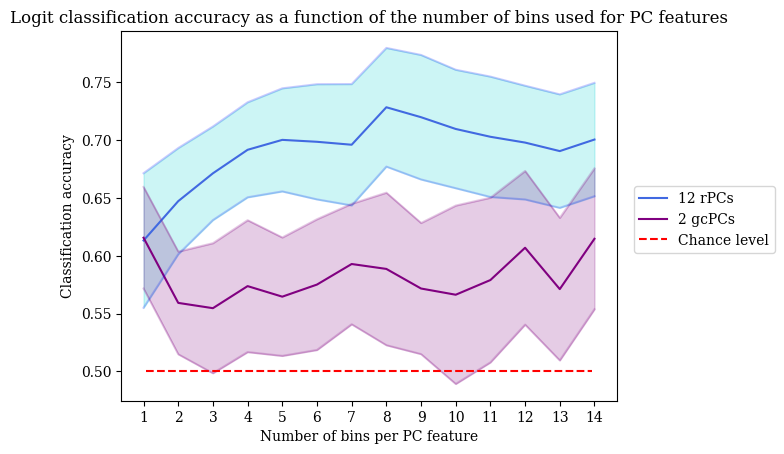

In [77]:
# Plot accuracy with error bars (standard error of the mean across folds) as a function of the number of bins used for gcPC features

# rPCA_accuracy = np.load('rPCA_outputs.npy', allow_pickle=True).item()['accuracy']
# rPCA_var = np.load('rPCA_outputs.npy', allow_pickle=True).item()['variance']

rPCA_upper = np.array(rPCA_accuracy) + np.array(rPCA_var) / np.sqrt(n_splits)
rPCA_lower = np.array(rPCA_accuracy) - np.array(rPCA_var) / np.sqrt(n_splits)
gcPCA_upper = np.array(gcPCA_accuracy) + np.array(gcPCA_var) / np.sqrt(n_splits)
gcPCA_lower = np.array(gcPCA_accuracy) - np.array(gcPCA_var) / np.sqrt(n_splits)

plt.plot(rPCA_accuracy, color='royalblue', label='12 rPCs')
plt.plot(gcPCA_accuracy, color='purple', label='2 gcPCs')

plt.plot(rPCA_upper, color='blue', alpha=0.2)
plt.plot(rPCA_lower, color='blue',alpha=0.2)
plt.plot(gcPCA_upper, color='purple', alpha=0.2)
plt.plot(gcPCA_lower, color='purple',alpha=0.2)

plt.fill_between(n_bins-1, rPCA_lower, rPCA_upper, color='darkturquoise', alpha=0.2)
plt.fill_between(n_bins-1, gcPCA_lower, gcPCA_upper, color='purple', alpha=0.2)

plt.axhline(0.5, xmin=0.05, xmax=0.95, color='red', linestyle='--', label='Chance level')
plt.xlabel('Number of bins per PC feature')
plt.xticks(n_bins-1, labels=[f'{int(x+1)}' for x in n_bins-1])
plt.ylabel('Classification accuracy')
plt.title('Logit classification accuracy as a function of the number of bins used for PC features')
plt.legend(bbox_to_anchor=(1.02, 0.6))
plt.show()

In [17]:
# TODO: Compare with traditional time-frequency analysis (nub of bursts, peak_ampl_burst, ...) results
# Great results with rPCA but what about the traditi methods? 